# Visualizing Images and Spectra

In [2]:
import numpy as np                                # to do math
import matplotlib.pyplot as plt                   # plotting functions
import os                                         # universal os
from astroquery.sdss import SDSS                  # to query SDSS spectra
from astropy import coordinates as coords         # to save astronomical coordinates for objects
import astropy.units as u                         # convenient unit conversion

import warnings                                   # ... ignore warnings
warnings.filterwarnings('ignore')

## Astronomical Data

The <font color="red">Sloan Digital Sky Survey (SDSS)</font> is one of the most influential astronomical surveys in history. In this notebook, we will use photometric and spectroscopic data from SDSS. These two types of astronomical data are methods of studying the light (or "intensity" or "flux" or "luminosity") emitted from astronomical objects. They are defined below:

<font color="red">Photometry or Imaging</font> - light is collected using photometric filters. These filters act as "light buckets", collecting light that is emitted across a broad wavelength range.

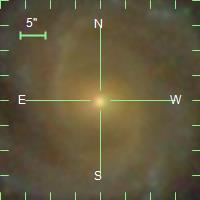

<font color="red">Spectroscopy</font> - light is split into many individual wavelengths using a prism or diffraction grating.

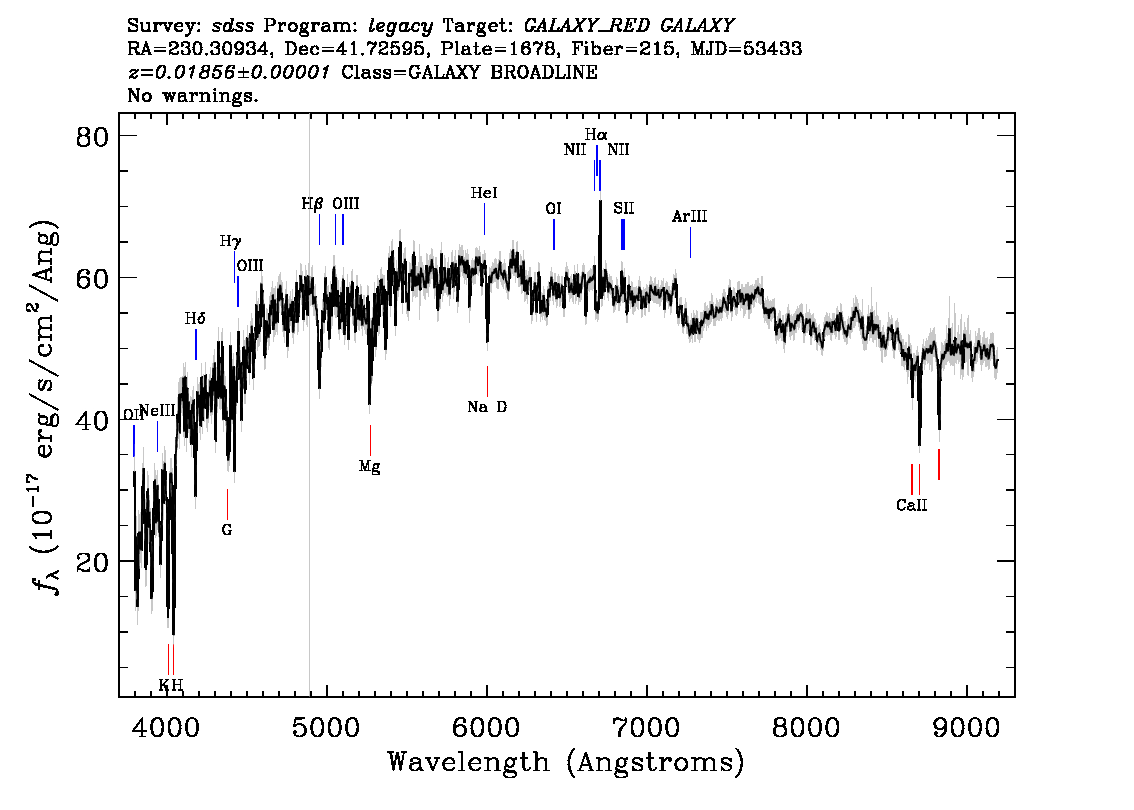

Both of these methods measure light as a function of wavelength. The granularity of this measurement is coarse with photometry and fine with spectroscopy. Thus, spectra are more favorable - but more expensive ! We will be looking at both of these types of data.

## Retrieving Data

Open [SkyServer SDSS](https://skyserver.sdss.org/dr19/VisualTools/navi). This is an interactive image of an area of sky observed by SDSS. By default, it should center on two galaxies merging - which is cool! 

Click "Select Objects" on the left panel and choose "Optical Spectra DR18" and "Optical Spectra DR19". This will overlay squares for each object which has a measured spectrum. Explore the image and pick out an object :) 

To retrieve its spectrum, we will query the SDSS archive using `astroquery`. For this, we need basic information on either the ID or the coordinates of the object you want to retrieve. We will use its coordinates. Right click on the object and copy its right-ascension (RA) and declination (DEC) coordinates. 

In [3]:
# try to query spectra from SDSS archive
try:

    # save coordinates
    # ~~~~~~~~~~~~~~~ input coordinates here ! ~~~~~~~~~~~~~~~
    pos = coords.SkyCoord(ra = 229.355308 * u.deg, dec = 42.9558051 * u.deg, frame = 'icrs')
    # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

    # retrieve it
    spec = SDSS.get_spectra(coordinates = pos, radius = 5 * u.arcsec)# plate=plate,mjd=mjd,fiberID=fiber)

    if spec is not None:

        hdu = spec[0]  # header-data unit (hdu)

        # ----------- saving spectral data ------------

        # ID
        plate = hdu[2].data['PLATE'][0]
        mjd = hdu[2].data['MJD'][0]
        fiberid = hdu[2].data['FIBERID'][0]

        # classification from SDSS
        classification = hdu[2].data['CLASS'][0]

        # spectroscopic redshift
        z = hdu[2].data['Z'][0]

        # flux
        flux_density_factor = hdu[1].data['flux']       # 10^-17 * [ergs / s / cm^2 / A]
        flux_density = 10**(-17) * flux_density_factor  # [ergs / s / cm^2 / A]

        # flux error
        ivar = hdu[1].data['ivar']
        flux_density_err = np.zeros_like(flux_density)
        good = ivar > 0    # avoid dividing by zero
        flux_density_err[good] = 1e-17 / np.sqrt(ivar[good])

        # wavelength
        log_wav = hdu[1].data['loglam']
        wavelength = 10**log_wav         # [A]

        # ----------------------------------------------

        print('\nspectrum successfully saved', end='\n\n')

# if unable to find spectra, give exception
except Exception as e:
    print(f"\nFailed to retrieve spectrum: {e}")



spectrum successfully saved



## Visualizing Spectra

Now, let's use the `Matplotlib` Python package to visualize our data.

First, it is convention to convert spectra from observed-frame to rest-frame. This makes it easier to identify spectral features.

In [4]:
# convert spectrum from observed frame to rest frame using the object's redshift
rest_frame_wavelength = wavelength / (1+z)
rest_frame_flux_density = flux_density * (1+z)
rest_frame_flux_density_err = flux_density_err * (1+z)

Let's plot it !

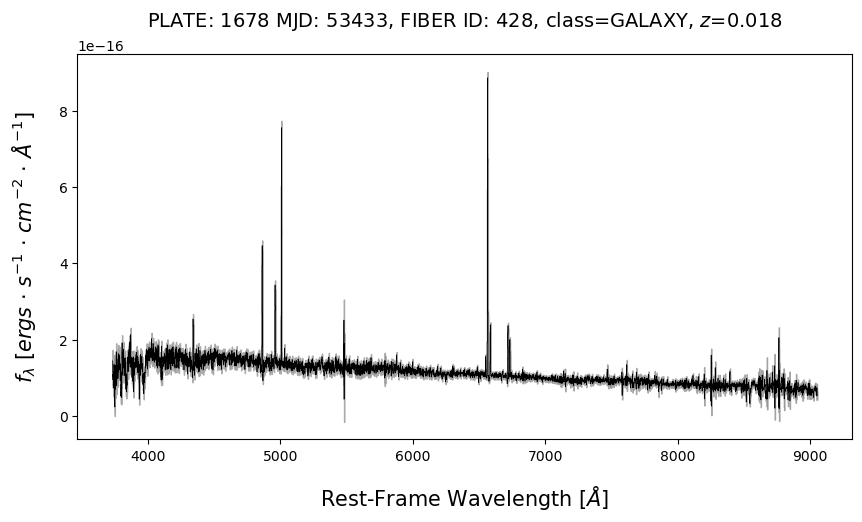

In [5]:
# initializing our figure
plt.figure(figsize=(10,5))

# labeling our axes
plt.title(f"PLATE: {plate} MJD: {mjd}, FIBER ID: {fiberid}, class={classification}, $z$={z:.3f}",fontsize=14, pad=20)
plt.xlabel(r'Rest-Frame Wavelength [$\AA$]', fontsize=15, labelpad=15)
plt.ylabel(r'$f_{\lambda}$ [$ergs$ $\cdot$ $s^{-1}$ $\cdot$ $cm^{-2}$ $\cdot$ $\AA^{-1}$]', fontsize=15, labelpad=15)

# plot spectrum
plt.step(rest_frame_wavelength, rest_frame_flux_density, where='mid', color='black', linewidth=0.5)

# flux errors shown by shaded region
upper = rest_frame_flux_density + rest_frame_flux_density_err
lower = rest_frame_flux_density - rest_frame_flux_density_err
plt.fill_between(rest_frame_wavelength, lower, upper, step='mid', color='black', alpha=0.3)

# saving and displaying figure
fig_name = f'{plate}_{mjd}_{fiberid}_spectrum.png'  
file_path = os.path.join('plots', fig_name)
plt.savefig(file_path, dpi=500, bbox_inches='tight')
plt.show()

### Scaling the y-axis

Depending on your source, some of the bumps and wiggles in the spectrum can be very large compared to the continuum emission. The spectrum might also has significant noise contamination... these things can scale the figure out too far.

We can focus on fainter features by scaling this spectrum down relative to the continuum level emission. Here is an example:

In [6]:
# compute the median flux value (which approximates the continuum level emission)
median_flux = np.median(rest_frame_flux_density)

In [7]:
# ~~~~~~~~~~~~~~ try updating the lower and upper factors ~~~~~~~~~~~~~~
lower_y_lim = median_flux * 0.25
upper_y_lim = median_flux * 2.5
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

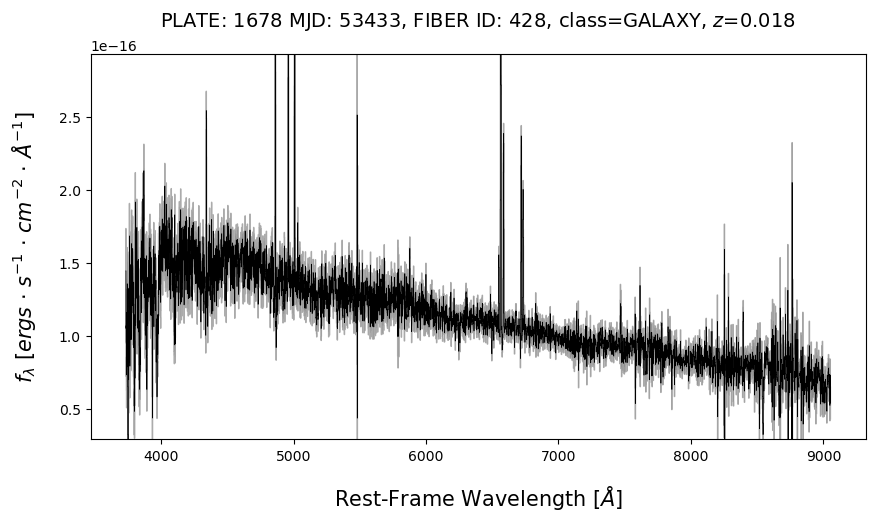

In [8]:
# initializing our figure
plt.figure(figsize=(10,5))

# labeling our axes
plt.title(f"PLATE: {plate} MJD: {mjd}, FIBER ID: {fiberid}, class={classification}, $z$={z:.3f}",fontsize=14, pad=20)
plt.xlabel(r'Rest-Frame Wavelength [$\AA$]', fontsize=15, labelpad=15)
plt.ylabel(r'$f_{\lambda}$ [$ergs$ $\cdot$ $s^{-1}$ $\cdot$ $cm^{-2}$ $\cdot$ $\AA^{-1}$]', fontsize=15, labelpad=15)

# plot spectrum
plt.step(rest_frame_wavelength, rest_frame_flux_density, where='mid', color='black', linewidth=0.5)

# flux errors shown by shaded region
upper = rest_frame_flux_density + rest_frame_flux_density_err
lower = rest_frame_flux_density - rest_frame_flux_density_err
plt.fill_between(rest_frame_wavelength, lower, upper, step='mid', color='black', alpha=0.3)

# apply scaling factors to y-axis
plt.ylim(lower_y_lim, upper_y_lim)

# saving and displaying figure
fig_name = f'{plate}_{mjd}_{fiberid}_spectrum_zoom_1.png'  
file_path = os.path.join('plots', fig_name)
plt.savefig(file_path, dpi=500, bbox_inches='tight')
plt.show()

### Scaling the x-axis

If we are interested in a particular spectral feature, say the H-alpha line, we can also set limits on our x-axis. Here is an example:

In [9]:
# ~~~~~~~~~~~~~~ try updating the lower and upper factors ~~~~~~~~~~~~~~
lower_y_lim = median_flux * 0.25
upper_y_lim = median_flux * 8
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# ~~~~~~~~~~ try with a different line or modify window size  ~~~~~~~~~~
H_alpha_str = 'H-alpha'            # name of the spectral feature
H_alpha_rest_wavelength = 6562.8   # rest-frame wavlength in Angstroms

lower_x_lim = H_alpha_rest_wavelength - 80   # create a window around the spectral feature
upper_x_lim = H_alpha_rest_wavelength + 80   # ''
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

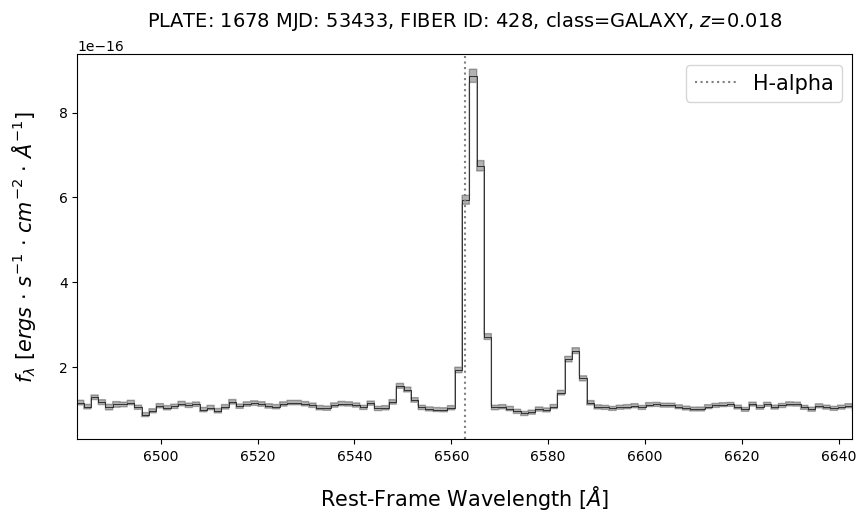

In [10]:
# initializing our figure
plt.figure(figsize=(10,5))

# labeling our axes
plt.title(f"PLATE: {plate} MJD: {mjd}, FIBER ID: {fiberid}, class={classification}, $z$={z:.3f}",fontsize=14, pad=20)
plt.xlabel(r'Rest-Frame Wavelength [$\AA$]', fontsize=15, labelpad=15)
plt.ylabel(r'$f_{\lambda}$ [$ergs$ $\cdot$ $s^{-1}$ $\cdot$ $cm^{-2}$ $\cdot$ $\AA^{-1}$]', fontsize=15, labelpad=15)

# plot spectrum
plt.step(rest_frame_wavelength, rest_frame_flux_density, where='mid', color='black', linewidth=0.5)

# indicate where the our line of interest is located
plt.axvline(H_alpha_rest_wavelength, color='grey', linestyle='dotted', label=f'{H_alpha_str}')

# flux errors shown by shaded region
upper = rest_frame_flux_density + rest_frame_flux_density_err
lower = rest_frame_flux_density - rest_frame_flux_density_err
plt.fill_between(rest_frame_wavelength, lower, upper, step='mid', color='black', alpha=0.3)

# apply scaling factors to y-axis
plt.ylim(lower_y_lim, upper_y_lim)

# limiting our x-axis to focus on a particular spectral feature
plt.xlim(lower_x_lim, upper_x_lim)

# add a legend
plt.legend(loc='upper right', fontsize=15)

# saving and displaying figure
fig_name = f'{plate}_{mjd}_{fiberid}_spectrum_zoom_2.png'  
file_path = os.path.join('plots', fig_name)
plt.savefig(file_path, dpi=500, bbox_inches='tight')
plt.show()

These are some basic methods for handling and visualizing spectra, which can be used as a starting point for your own spectral visualizations!